In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
BASE_DIR = "/content/drive/MyDrive/intentmap-nids/intentmap-nids"

In [57]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/intentmap-nids/intentmap-nids")

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR)

Data directory: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed


In [58]:
import os

print(os.listdir(DATA_DIR))

['val_normal.npz', 'test_dedup.npz', 'test_full.npz', 'train_normal.npz', 'models', 'reports', 'config']


In [59]:
%cd /content//drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
!ls

/content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
config	reports		test_full.npz	  val_normal.npz
models	test_dedup.npz	train_normal.npz


In [60]:
import numpy as np

DATA_DIR = "/content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed"

train_data = np.load(f"{DATA_DIR}/train_normal.npz")
val_data   = np.load(f"{DATA_DIR}/val_normal.npz")
test_data  = np.load(f"{DATA_DIR}/test_full.npz")

print("Train keys:", train_data.files)
print("Validation keys:", val_data.files)
print("Test keys:", test_data.files)

Train keys: ['X']
Validation keys: ['X']
Test keys: ['X', 'y']


In [61]:
X_train = train_data["X"]
X_val = val_data["X"]
X_test = test_data["X"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (41065, 41)
Validation: (10266, 41)
Test: (82332, 41)


In [62]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed")
print("Data folder exists:", DATA_DIR.exists())
print("Files:", [f.name for f in DATA_DIR.iterdir()])

def load_npz(path):
    data = np.load(path)
    X = data["X"]
    y = data["y"] if "y" in data.files else None
    return X, y

X_train, _ = load_npz(DATA_DIR / "train_normal.npz")
X_val, _ = load_npz(DATA_DIR / "val_normal.npz")
X_test, y_test = load_npz(DATA_DIR / "test_full.npz")


print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)
print("Normal test records:", (y_test == 0).sum())
print("Attack test records:", (y_test == 1).sum())

Data folder exists: True
Files: ['val_normal.npz', 'test_dedup.npz', 'test_full.npz', 'train_normal.npz', 'models', 'reports', 'config']
Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [63]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


model_1 = IsolationForest(
    n_estimators=300,
    max_samples=0.8,
    max_features=1.0,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest Candidate 1...")
model_1.fit(X_train)
print("Training completed.")

# Higher score means more anomalous
validation_scores = -model_1.score_samples(X_val)
test_scores = -model_1.score_samples(X_test)

# Set threshold using a 1% false-positive budget
threshold_1pct = np.quantile(validation_scores, 0.99)
predictions = (test_scores >= threshold_1pct).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test, predictions, labels=[0, 1]
).ravel()

precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)
fpr = fp / (fp + tn)
roc_auc = roc_auc_score(y_test, test_scores)
pr_auc = average_precision_score(y_test, test_scores)

print("\nIsolation Forest Candidate 1 Results")
print("------------------------------------")
print("Threshold:", round(threshold_1pct, 4))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))
print("False-positive rate:", f"{fpr:.2%}")
print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))
print("Confusion matrix:")
print([[tn, fp], [fn, tp]])

Training Isolation Forest Candidate 1...
Training completed.

Isolation Forest Candidate 1 Results
------------------------------------
Threshold: 0.5461
Precision: 0.94
Recall: 0.617
F1-score: 0.745
False-positive rate: 4.82%
ROC-AUC: 0.851
PR-AUC: 0.897
Confusion matrix:
[[np.int64(35217), np.int64(1783)], [np.int64(17359), np.int64(27973)]]


In [64]:
import pandas as pd

budget_results = []

for budget in [0.005, 0.01, 0.03]:
    threshold = np.quantile(validation_scores, 1 - budget)
    prediction = (test_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, prediction, labels=[0, 1]
    ).ravel()

    budget_results.append({
        "Budget": f"{budget:.1%}",
        "Threshold": round(threshold, 4),
        "Precision": round(
            precision_score(y_test, prediction, zero_division=0), 3
        ),
        "Recall": round(
            recall_score(y_test, prediction, zero_division=0), 3
        ),
        "F1-score": round(
            f1_score(y_test, prediction, zero_division=0), 3
        ),
        "Actual FPR": f"{fp / (fp + tn):.2%}",
        "False alerts per 1000": round(fp / (fp + tn) * 1000, 1)
    })

results_table = pd.DataFrame(budget_results)
results_table

,Budget,Threshold,Precision,Recall,F1-score,Actual FPR,False alerts per 1000
0,0.5%,0.5676,0.949,0.609,0.742,3.97%,39.7
1,1.0%,0.5461,0.940,0.617,0.745,4.82%,48.2
2,3.0%,0.4966,0.905,0.664,0.766,8.53%,85.3


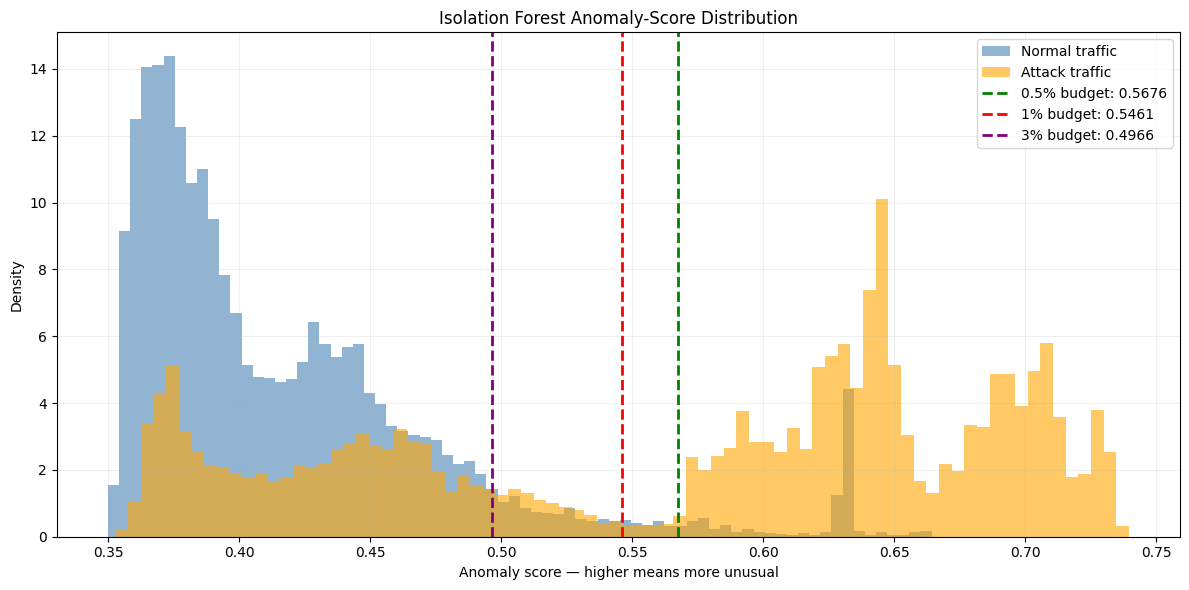

In [65]:
import matplotlib.pyplot as plt

normal_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test == 1]

thresholds = {
    "0.5% budget": np.quantile(validation_scores, 0.995),
    "1% budget": np.quantile(validation_scores, 0.99),
    "3% budget": np.quantile(validation_scores, 0.97)
}

plt.figure(figsize=(12, 6))

plt.hist(
    normal_scores,
    bins=80,
    density=True,
    alpha=0.6,
    label="Normal traffic",
    color="steelblue"
)

plt.hist(
    attack_scores,
    bins=80,
    density=True,
    alpha=0.6,
    label="Attack traffic",
    color="orange"
)

colours = ["green", "red", "purple"]

for (label, threshold), colour in zip(thresholds.items(), colours):
    plt.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        color=colour,
        label=f"{label}: {threshold:.4f}"
    )

plt.title("Isolation Forest Anomaly-Score Distribution")
plt.xlabel("Anomaly score — higher means more unusual")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/isolation_forest_scores.png", dpi=150)
plt.show()

In [66]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

REPORT_DIR = BASE_DIR / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

threshold_005 = thresholds["0.5% budget"]
threshold_01  = thresholds["1% budget"]
threshold_03  = thresholds["3% budget"]

pred_005 = (test_scores >= threshold_005).astype(int)
pred_01  = (test_scores >= threshold_01).astype(int)
pred_03  = (test_scores >= threshold_03).astype(int)

dashboard_results = pd.DataFrame({
    "record_id": range(1, len(test_scores) + 1),
    "actual_label": y_test,
    "actual_class": [
        "Attack" if y == 1 else "Normal"
        for y in y_test
    ],
    "if_score": test_scores,

    "if_prediction_0.5pct": pred_005,
    "if_prediction_1pct": pred_01,
    "if_prediction_3pct": pred_03,

    "if_status_0.5pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in pred_005
    ],
    "if_status_1pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in pred_01
    ],
    "if_status_3pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in pred_03
    ]
})

# 1% budget = default dashboard view
dashboard_results["default_threshold"] = threshold_01
dashboard_results["default_prediction"] = pred_01
dashboard_results["default_status"] = [
    "Anomaly" if p == 1 else "Normal"
    for p in pred_01
]

dashboard_results["correct_prediction"] = (
    dashboard_results["default_prediction"]
    == dashboard_results["actual_label"]
)

DASHBOARD_FILE = (
    REPORT_DIR / "isolation_forest_dashboard_results.csv"
)

dashboard_results.to_csv(
    DASHBOARD_FILE,
    index=False
)

print("Dashboard file saved to:")
print(DASHBOARD_FILE)

print("Shape:", dashboard_results.shape)

display(dashboard_results.head(10))

Dashboard file saved to:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/isolation_forest_dashboard_results.csv
Shape: (82332, 14)


,record_id,actual_label,actual_class,if_score,if_prediction_0.5pct,if_prediction_1pct,if_prediction_3pct,if_status_0.5pct,if_status_1pct,if_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,0.450713,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
1,2,0,Normal,0.463685,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
2,3,0,Normal,0.439728,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
3,4,0,Normal,0.441019,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
4,5,0,Normal,0.460208,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
5,6,0,Normal,0.464486,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
6,7,0,Normal,0.473945,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
7,8,0,Normal,0.482098,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
8,9,0,Normal,0.630057,1,1,1,Anomaly,Anomaly,Anomaly,0.546054,1,Anomaly,False
9,10,0,Normal,0.630057,1,1,1,Anomaly,Anomaly,Anomaly,0.546054,1,Anomaly,False


In [67]:
import joblib
import json
from pathlib import Path

Path("models").mkdir(exist_ok=True)
Path("reports").mkdir(exist_ok=True)
Path("config").mkdir(exist_ok=True)

# Save your trained candidate model
joblib.dump(
    model_1,
    "models/isolation_forest_candidate1.joblib"
)

# Save the budget comparison table
results_table.to_csv(
    "reports/budget_results.csv",
    index=False
)

# Save model settings and thresholds
model_information = {
    "model": "Isolation Forest",
    "author": "Syed Rubaiyat Karim",
    "purpose": "Candidate model for comparison, not final production model",
    "n_estimators": 300,
    "max_samples": 0.8,
    "max_features": 1.0,
    "random_state": 42,
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "thresholds": {
        label: float(value)
        for label, value in thresholds.items()
    }
}

with open(
    "config/isolation_forest_candidate1.json",
    "w"
) as file:
    json.dump(model_information, file, indent=4)

print("Model and results saved successfully.")
print("Saved model: models/isolation_forest_candidate1.joblib")
print("Saved table: reports/budget_results.csv")
print("Saved graph: reports/isolation_forest_scores.png")
print("Saved configuration: config/isolation_forest_candidate1.json")

Model and results saved successfully.
Saved model: models/isolation_forest_candidate1.joblib
Saved table: reports/budget_results.csv
Saved graph: reports/isolation_forest_scores.png
Saved configuration: config/isolation_forest_candidate1.json


In [68]:
!zip -j /content/Isolation_Forest_Results.zip \
models/isolation_forest_candidate1.joblib \
reports/budget_results.csv \
/content/isolation_forest_scores.png \
reports/isolation_forest_dashboard_results.csv \
config/isolation_forest_candidate1.json

from google.colab import files
files.download("/content/Isolation_Forest_Results.zip")

updating: isolation_forest_candidate1.joblib (deflated 72%)
updating: budget_results.csv (deflated 25%)
updating: isolation_forest_dashboard_results.csv (deflated 89%)
  adding: isolation_forest_candidate1.json (deflated 42%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>